# MCDI500 — Fase 2: Notebook de obtención, limpieza y transformación de datos

**Proyecto:** Análisis predictivo de diabetes  
**Integrantes:** Daniel Hormazábal, Cristian Pasten, Enso Guidotti  
**Curso:** MCDI500 — Programación para la Ciencia de Datos  
**Docente:** Omar Salinas Silva  
**Fecha:** 09-06-2026  

---

## Tabla de contenidos

1. [Importación y configuración del entorno](#seccion-1)
2. [Carga del dataset](#seccion-2)
3. [Exploración estructural](#seccion-3)
4. [Detección de anomalías](#seccion-4)
5. [Limpieza del dataset](#seccion-5)
6. [Transformación de variables](#seccion-6)
7. [Validación del dataset final](#seccion-7)
8. [Exportación](#seccion-8)
9. [Resumen del pipeline](#seccion-9)
10. [Bibliografía](#seccion-biblio)


<a id="seccion-1"></a>

---
## 1. Importación de librerías y configuración del entorno

Se importan las mismas librerías declaradas en el `requirements.txt` de la Fase 1. La verificación de versiones garantiza coherencia con el entorno reproducible configurado previamente (VanderPlas, 2023).

In [ ]:
import pandas as pd          # Manipulación y análisis de datos tabulares (McKinney, 2022)
import numpy as np           # Cómputo numérico
import matplotlib.pyplot as plt  # Visualización exploratoria
import os

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Verificación de versiones del entorno
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print("\nLibrerías importadas correctamente ✓")

pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4

Librerías importadas correctamente ✓


<a id="seccion-2"></a>

---
## 2. Carga del dataset

Se carga el archivo crudo desde `data/raw/diabetes.csv`, que corresponde a la versión extendida de 15.000 registros del *Pima Indians Diabetes Database* obtenida desde Kaggle (Mathchi, 2023). El archivo crudo **no se modifica en ningún momento**; todas las transformaciones se aplican sobre copias del DataFrame, siguiendo el principio de inmutabilidad de los datos originales.

In [ ]:
def cargar_datos(ruta):
    # Carga el dataset crudo desde la ruta especificada.
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")
    
    df = pd.read_csv(ruta)
    print(f"Dataset cargado correctamente ✓")
    print(f"Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"Columnas    : {df.columns.tolist()}")
    return df


# Ejecución — ajustar ruta según la ubicación del repositorio
ruta_dataset = '../data/raw/diabetes.csv'
df_raw = cargar_datos(ruta_dataset)

Dataset cargado correctamente ✓
Dimensiones : 15,000 filas × 10 columnas
Columnas    : ['PatientID', 'Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']


<a id="seccion-3"></a>

---
## 3. Exploración estructural del dataset

Antes de aplicar cualquier transformación, se realiza un diagnóstico completo del dataset. Esta etapa responde a la fase de *Data Understanding* del marco CRISP-DM y proporciona la base para todas las decisiones de limpieza posteriores (UNAB, 2026b).

Las variables del dataset son:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `PatientID` | int | Identificador único del paciente (sin valor predictivo) |
| `Pregnancies` | int | Número de embarazos |
| `PlasmaGlucose` | int | Glucosa plasmática en test oral de tolerancia |
| `DiastolicBloodPressure` | int | Presión arterial diastólica (mm Hg) |
| `TricepsThickness` | int | Grosor del pliegue cutáneo tricipital (mm) |
| `SerumInsulin` | int | Insulina sérica a las 2 horas (mu U/ml) |
| `BMI` | float | Índice de masa corporal (kg/m²) |
| `DiabetesPedigree` | float | Función pedigrí de diabetes |
| `Age` | int | Edad en años |
| `Diabetic` | int | Variable objetivo: 0 = no diabético, 1 = diabético |

In [ ]:
def explorar_dataset(df):
    """
    Realiza un diagnóstico estructural completo del DataFrame:
    tipos de datos, estadísticos descriptivos, valores nulos,
    duplicados y distribución de la variable objetivo.
    """

    print("1. INFORMACIÓN GENERAL DEL DATASET\n")
    print(df.info())

    print("\n2. ESTADÍSTICOS DESCRIPTIVOS\n")
    print(df.describe().round(2))

    print("\n3. VALORES NULOS POR COLUMNA\n")
    nulos = df.isnull().sum()
    print(nulos[nulos >= 0].to_string())
    print(f"\nTotal celdas nulas: {df.isnull().sum().sum()}")

    print("\n4. FILAS DUPLICADAS\n")
    print(f"Filas duplicadas: {df.duplicated().sum()}")

    print("\n5. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Diabetic) \n")
    conteo = df['Diabetic'].value_counts()
    pct = df['Diabetic'].value_counts(normalize=True) * 100
    resumen = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct.round(1)})
    resumen.index = resumen.index.map({0: 'No diabético (0)', 1: 'Diabético (1)'})
    print(resumen)


explorar_dataset(df_raw)

1. INFORMACIÓN GENERAL DEL DATASET

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               15000 non-null  int64  
 1   Pregnancies             15000 non-null  int64  
 2   PlasmaGlucose           15000 non-null  int64  
 3   DiastolicBloodPressure  15000 non-null  int64  
 4   TricepsThickness        15000 non-null  int64  
 5   SerumInsulin            15000 non-null  int64  
 6   BMI                     15000 non-null  float64
 7   DiabetesPedigree        15000 non-null  float64
 8   Age                     15000 non-null  int64  
 9   Diabetic                15000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.1 MB
None

2. ESTADÍSTICOS DESCRIPTIVOS

        PatientID  Pregnancies  PlasmaGlucose  DiastolicBloodPressure  \
count    15000.00     15000.00       15000.00               

### 3.1 Visualización de la distribución de variables numéricas

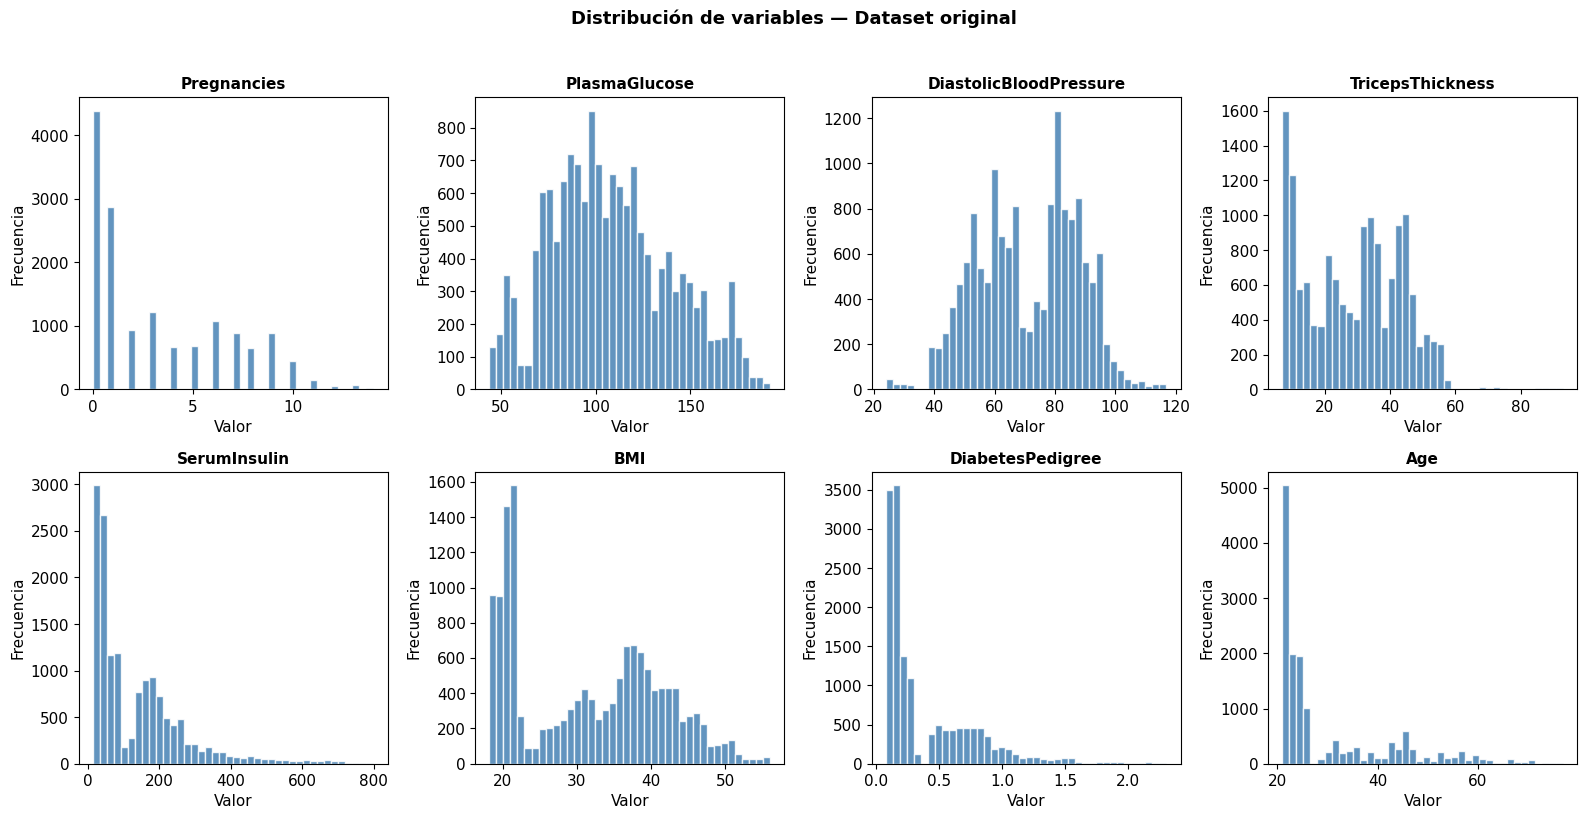

In [ ]:
# Visualización: histogramas de todas las variables numéricas
# Se excluye PatientID por ser un identificador sin valor analítico

cols_viz = [c for c in df_raw.columns if c not in ['PatientID', 'Diabetic']]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_viz):
    axes[i].hist(df_raw[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último eje si sobra
for j in range(len(cols_viz), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables — Dataset original', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# si deseamos guardar el gráfico, descomentar las siguientes líneas y ajustar la ruta si es necesario
#plt.savefig('../docs/F2_graficos/fig_distribucion_original.png', dpi=150, bbox_inches='tight')
# print("Figura guardada en docs/F2_graficos/fig_distribucion_original.png ✓")

<a id="seccion-4"></a>

---
## 4. Detección de anomalías

### 4.1 Análisis de ceros biológicamente inviables

En la versión clásica del *Pima Indians Diabetes Database* (768 registros), variables como glucosa, presión arterial e IMC presentan ceros que representan datos faltantes codificados incorrectamente. Para la versión extendida de 15.000 registros utilizada en este proyecto, se verifica si este problema persiste.

Un valor de **0 es biológicamente imposible** en las siguientes columnas:
- `PlasmaGlucose`: la glucosa en sangre no puede ser 0 en un paciente vivo.
- `DiastolicBloodPressure`: presión arterial 0 indica ausencia de pulso.
- `TricepsThickness`: el pliegue cutáneo no puede medir 0 mm.
- `SerumInsulin`: la insulina sérica no puede ser 0 en ausencia de patología severa.
- `BMI`: un IMC de 0 es físicamente imposible.

**Nota:** `Pregnancies` puede legítimamente ser 0 (paciente nunca embarazada), por lo que **no se considera anómalo**.

In [34]:
def detectar_anomalias(df):
    """
    Detecta valores potencialmente anómalos en el dataset.
    Revisa ceros en columnas biológicamente críticas y
    valores fuera de rangos clínicamente plausibles.
    """
    # Columnas donde 0 es biológicamente inviable
    cols_bio = [
        'PlasmaGlucose', 'DiastolicBloodPressure',
        'TricepsThickness', 'SerumInsulin', 'BMI'
    ]

    print("CEROS EN COLUMNAS BIOLÓGICAMENTE CRÍTICAS\n")

    resultados = []
    # Revisa cada columna crítica por ceros y calcula su porcentaje
    for col in cols_bio:
        n_ceros = (df[col] == 0).sum()
        pct = n_ceros / len(df) * 100
        resultados.append({'Columna': col, 'Ceros': n_ceros, 'Porcentaje (%)': round(pct, 2)})

    tabla = pd.DataFrame(resultados).set_index('Columna')
    print(tabla)

    print("\nRANGOS OBSERVADOS VS. RANGOS CLÍNICOS PLAUSIBLES\n")

    # Rangos de referencia clínica (aproximados)
    rangos_ref = {
        'PlasmaGlucose':         (40, 500,  'mg/dL'),
        'DiastolicBloodPressure':(20, 130,  'mm Hg'),
        'TricepsThickness':      (1,  100,  'mm'),
        'SerumInsulin':          (1,  850,  'mu U/ml'),
        'BMI':                   (10, 70,   'kg/m²'),
        'Age':                   (18, 110,  'años'),
    }

    for col, (lo, hi, unidad) in rangos_ref.items():
        fuera = ((df[col] < lo) | (df[col] > hi)).sum()
        obs_min = df[col].min()
        obs_max = df[col].max()
        estado = "✓ OK" if fuera == 0 else f"⚠ {fuera} valores fuera"
        print(f"  {col:<28} [{obs_min:.1f} – {obs_max:.1f}] {unidad:<10} → {estado}")

    return tabla


tabla_anomalias = detectar_anomalias(df_raw)

CEROS EN COLUMNAS BIOLÓGICAMENTE CRÍTICAS

                        Ceros  Porcentaje (%)
Columna                                      
PlasmaGlucose               0             0.0
DiastolicBloodPressure      0             0.0
TricepsThickness            0             0.0
SerumInsulin                0             0.0
BMI                         0             0.0

RANGOS OBSERVADOS VS. RANGOS CLÍNICOS PLAUSIBLES

  PlasmaGlucose                [44.0 – 192.0] mg/dL      → ✓ OK
  DiastolicBloodPressure       [24.0 – 117.0] mm Hg      → ✓ OK
  TricepsThickness             [7.0 – 93.0] mm         → ✓ OK
  SerumInsulin                 [14.0 – 799.0] mu U/ml    → ✓ OK
  BMI                          [18.2 – 56.0] kg/m²      → ✓ OK
  Age                          [21.0 – 77.0] años       → ✓ OK


### 4.2 Interpretación del diagnóstico

La exploración revela que el dataset extendido de 15.000 registros **no presenta ceros en las columnas biológicamente críticas** (PlasmaGlucose, DiastolicBloodPressure, TricepsThickness, SerumInsulin, BMI), a diferencia de la versión clásica de 768 registros. Esto indica que el proceso de generación del dataset extendido ya aplicó algún tipo de tratamiento o que los datos provienen de una fuente curada.

Los únicos ceros presentes son:
- **`Pregnancies`**: esperados y válidos (pacientes sin embarazos previos).
- **`Diabetic`**: ceros son la clase 0 (no diabético), completamente válidos.

**Decisión técnica:** No se requiere imputación de ceros. Sin embargo, se realiza igualmente el pipeline de limpieza completo para verificar nulos, duplicados y consistencia general del dataset, asegurando robustez antes del modelado.

<a id="seccion-5"></a>

---
## 5. Limpieza del dataset

### Estrategia de limpieza

Con base en el diagnóstico anterior, se aplica la siguiente estrategia:

| Problema detectado | Decisión | Justificación |
|--------------------|----------|---------------|
| Valores nulos | No existen | Dataset completo |
| Ceros biológicos | No existen | Dataset ya curado |
| Filas duplicadas | No existen | Dataset íntegro |
| `PatientID` | Excluir | Identificador sin valor predictivo; su inclusión generaría *data leakage* en el modelo |

Aunque no se detectaron valores faltantes, se implementa la función con capacidad de imputación por mediana, de modo que sea reutilizable en datasets con NA en fases posteriores del proyecto o en variantes del dataset.

In [ ]:
def limpiar_dataset(df, cols_imputar: list = None, estrategia = 'mediana'):
    """
    Aplica el flujo de limpieza al dataset:
        1. Elimina la columna PatientID (identificador sin valor predictivo).
        2. Elimina filas duplicadas.
        3. Imputa valores nulos en columnas especificadas.

    La función opera sobre una copia del DataFrame; el dataset
    crudo original permanece intacto (principio de inmutabilidad).
    """
    df_clean = df.copy()
    filas_inicial = len(df_clean)

    # Paso 1: Excluir PatientID
    if 'PatientID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['PatientID'])
        print("[1] PatientID excluida ✓")

    # Paso 2: Eliminar duplicados
    n_duplicados = df_clean.duplicated().sum()
    if n_duplicados > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"[2] {n_duplicados} filas duplicadas eliminadas ✓")
    else:
        print("[2] Sin filas duplicadas ✓")

    # Paso 3: Imputación de valores nulos
    cols_num = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    # No imputar la variable objetivo
    cols_num = [c for c in cols_num if c != 'Diabetic']
    target_cols = cols_imputar if cols_imputar else cols_num

    nulos_total = df_clean[target_cols].isnull().sum().sum()
    if nulos_total > 0:
        for col in target_cols:
            n_na = df_clean[col].isnull().sum()
            if n_na > 0:
                valor = df_clean[col].median() if estrategia == 'mediana' else df_clean[col].mean()
                df_clean[col] = df_clean[col].fillna(valor)
                print(f"[3] {col}: {n_na} NA imputados con {estrategia} = {valor:.4f} ✓")
    else:
        print(f"[3] Sin valores nulos en columnas numéricas ✓")

    # Resumen
    print(f"\n--- Resumen de limpieza ---")
    print(f"Filas antes : {filas_inicial:,}")
    print(f"Filas después: {len(df_clean):,}")
    print(f"Columnas    : {list(df_clean.columns)}")
    print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")

    return df_clean


# Ejecución
df_clean = limpiar_dataset(df_raw, estrategia='mediana')

[1] PatientID excluida ✓
[2] Sin filas duplicadas ✓
[3] Sin valores nulos en columnas numéricas ✓

--- Resumen de limpieza ---
Filas antes : 15,000
Filas después: 15,000
Columnas    : ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']
Nulos restantes: 0


<a id="seccion-6"></a>

---
## 6. Transformación de variables

### 6.1 Justificación de las transformaciones

Las transformaciones aplicadas en esta etapa tienen por objetivo **preparar el dataset para el modelado supervisado** de la Fase 3. Se aplican las siguientes operaciones:

| Transformación | Variables afectadas | Justificación técnica |
|----------------|--------------------|-----------------------|
| Verificación de tipos | Todas | Confirmar que los tipos de datos son los esperados antes de escalar |
| Normalización Min-Max | Variables numéricas continuas (no objetivo) | Iguala la escala de todas las variables; algoritmos como KNN y SVM son sensibles a la magnitud (The pandas development team, 2024) |
| Separación features/target | `X` / `y` | Estructura estándar requerida por scikit-learn para el entrenamiento del modelo en F3 |

**Decisión de diseño:** se implementa normalización Min-Max en lugar de estandarización Z-score porque los rangos clínicos de las variables son conocidos y acotados, lo que hace que el escalado a [0, 1] sea interpretable y apropiado (VanderPlas, 2023).

In [31]:
def verificar_tipos(df):
    """
    Verifica y reporta los tipos de datos de cada columna.
    Detecta columnas que requieren casting.
    """
    print("TIPOS DE DATOS POR COLUMNA\n")
    for col in df.columns:
        tipo = df[col].dtype
        n_unicos = df[col].nunique()
        print(f"  {col:<28} {str(tipo):<10}  ({n_unicos} valores únicos)")


verificar_tipos(df_clean)

TIPOS DE DATOS POR COLUMNA

  Pregnancies                  int64       (15 valores únicos)
  PlasmaGlucose                int64       (149 valores únicos)
  DiastolicBloodPressure       int64       (90 valores únicos)
  TricepsThickness             int64       (69 valores únicos)
  SerumInsulin                 int64       (663 valores únicos)
  BMI                          float64     (15000 valores únicos)
  DiabetesPedigree             float64     (14999 valores únicos)
  Age                          int64       (56 valores únicos)
  Diabetic                     int64       (2 valores únicos)


In [32]:
def normalizar_minmax(df, excluir: list = None):
    """
    Aplica normalización Min-Max a las columnas numéricas del DataFrame,
    escalando cada variable al rango [0, 1].

    La fórmula aplicada es: x_norm = (x - x_min) / (x_max - x_min)

    La variable objetivo (Diabetic) y las columnas especificadas
    en `excluir` quedan intactas.    
    """
    if excluir is None:
        excluir = []

    # Nunca normalizar la variable objetivo
    excluir_final = list(set(excluir + ['Diabetic']))

    df_norm = df.copy()
    cols_num = df_norm.select_dtypes(include=[np.number]).columns.tolist()
    cols_normalizar = [c for c in cols_num if c not in excluir_final]

    print("Normalización Min-Max aplicada:")
    for col in cols_normalizar:
        x_min = df_norm[col].min()
        x_max = df_norm[col].max()
        rango = x_max - x_min
        if rango == 0:
            print(f"  ⚠  {col}: rango = 0, columna constante — omitida")
            continue
        df_norm[col] = (df_norm[col] - x_min) / rango
        print(f"  ✓  {col:<28} [{x_min:.2f}, {x_max:.2f}] → [0.00, 1.00]")

    print(f"\nColumnas sin normalizar: {excluir_final}")
    return df_norm


# Ejecución — Pregnancies es discreta ordinal; también se normaliza
df_transformed = normalizar_minmax(df_clean)

Normalización Min-Max aplicada:
  ✓  Pregnancies                  [0.00, 14.00] → [0.00, 1.00]
  ✓  PlasmaGlucose                [44.00, 192.00] → [0.00, 1.00]
  ✓  DiastolicBloodPressure       [24.00, 117.00] → [0.00, 1.00]
  ✓  TricepsThickness             [7.00, 93.00] → [0.00, 1.00]
  ✓  SerumInsulin                 [14.00, 799.00] → [0.00, 1.00]
  ✓  BMI                          [18.20, 56.03] → [0.00, 1.00]
  ✓  DiabetesPedigree             [0.08, 2.30] → [0.00, 1.00]
  ✓  Age                          [21.00, 77.00] → [0.00, 1.00]

Columnas sin normalizar: ['Diabetic']


### 6.2 Separación features / target

Se genera la estructura estándar `X` (features) / `y` (target) requerida por scikit-learn para el entrenamiento del clasificador en la Fase 3. Esta separación se realiza aquí para verificar que el dataset transformado tiene la forma correcta antes de exportarlo.

In [ ]:
def separar_features_target(df, target_col = 'Diabetic'):
    
    # Separa el DataFrame en features (X) y variable objetivo (y).
    if target_col not in df.columns:
        raise ValueError(f"La columna objetivo '{target_col}' no existe en el DataFrame.")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    print(f"Features (X) : {X.shape[0]:,} filas × {X.shape[1]} columnas")
    print(f"Target   (y) : {y.shape[0]:,} valores")
    print(f"Columnas features: {X.columns.tolist()}")
    print(f"Distribución y   : {y.value_counts().to_dict()}")

    return X, y


X, y = separar_features_target(df_transformed)

Features (X) : 15,000 filas × 8 columnas
Target   (y) : 15,000 valores
Columnas features: ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']
Distribución y   : {0: 10000, 1: 5000}


### 6.3 Visualización comparativa: antes y después de la normalización

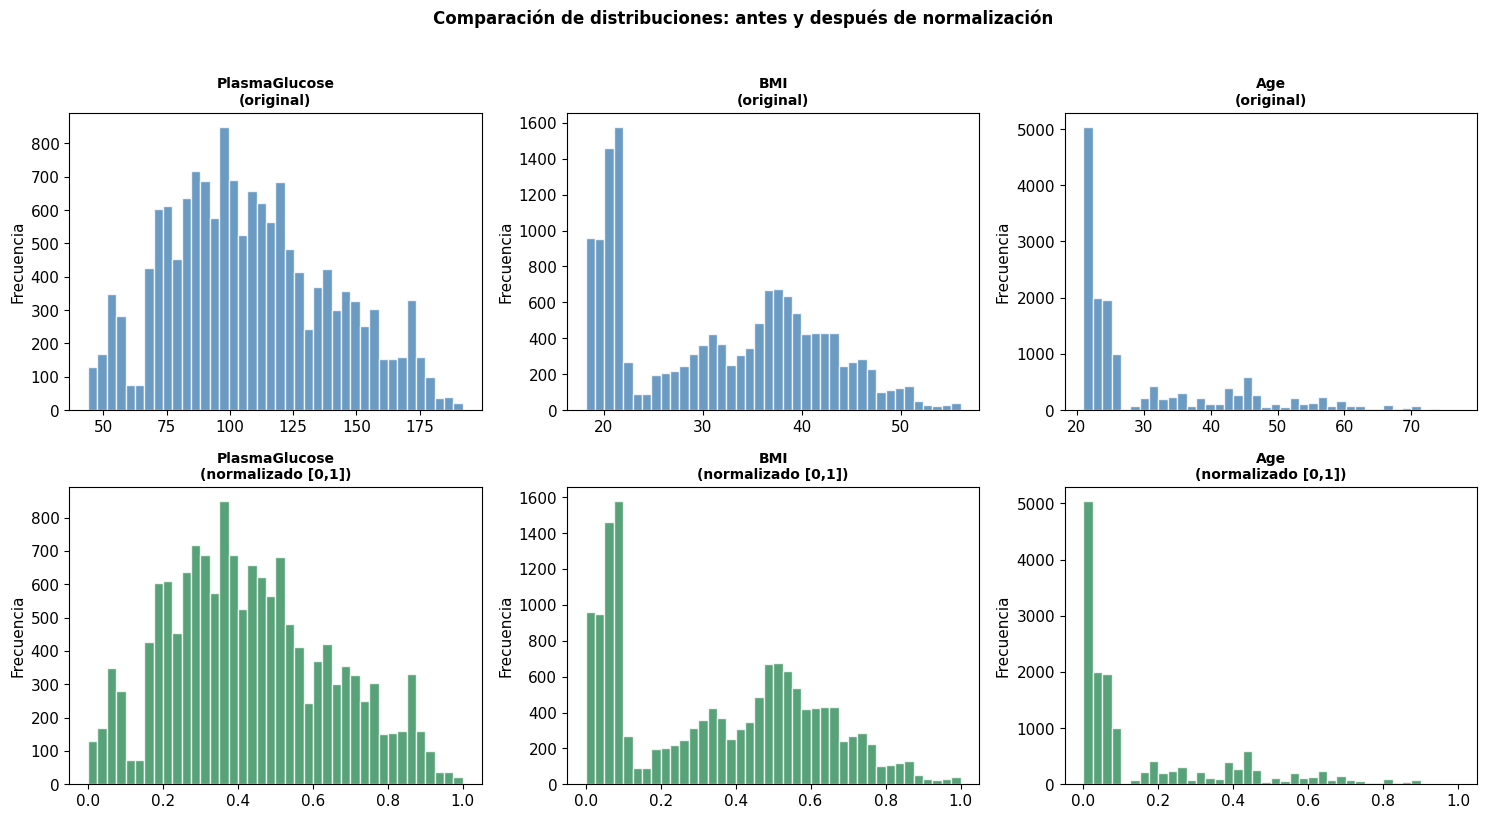

In [39]:
# Comparación visual de distribuciones antes y después de normalizar
# Se muestran 3 variables representativas

cols_ejemplo = ['PlasmaGlucose', 'BMI', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(cols_ejemplo):
    # Antes
    axes[0, i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(original)', fontsize=10, fontweight='bold')
    axes[0, i].set_ylabel('Frecuencia')

    # Después
    axes[1, i].hist(df_transformed[col], bins=40, color='seagreen', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(normalizado [0,1])', fontsize=10, fontweight='bold')
    axes[1, i].set_ylabel('Frecuencia')

plt.suptitle('Comparación de distribuciones: antes y después de normalización', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# si se desea guardar el gráfico, descomentar las siguientes líneas y ajustar la ruta si es necesario
# plt.savefig('../docs/F2_graficos/fig_comparacion_normalizacion.png', dpi=150, bbox_inches='tight')
# print("Figura guardada en docs/F2_graficos/fig_comparacion_normalizacion.png ✓")

<a id="seccion-7"></a>

---
## 7. Validación del dataset final

Antes de exportar, se ejecuta un conjunto de verificaciones formales que comprueban la integridad, consistencia y correcta estructura del dataset procesado. Se utilizan `assert` para fijar los supuestos del pipeline como condiciones verificables (UNAB, 2026b).

In [ ]:
def validar_dataset(df_original, df_procesado):
    """
    Valida la integridad del dataset procesado mediante comprobaciones
    formales (asserts) y reportes comparativos antes/después.

    Las comprobaciones cubren:
    - Ausencia de valores nulos.
    - Ausencia de filas duplicadas.
    - Integridad del número de filas.
    - Rango normalizado correcto [0, 1] para features.
    - Valores válidos en la variable objetivo.
    - Consistencia de tipos de datos.  
    """

    print("VALIDACIÓN DEL DATASET PROCESADO\n")
    # Test 1: Sin valores nulos
    nulos = df_procesado.isnull().sum().sum()
    assert nulos == 0, f"ERROR: {nulos} valores nulos encontrados."
    print(f"[✓] Test 1 — Sin valores nulos         : {nulos}")

    # Test 2: Sin duplicados
    dupl = df_procesado.duplicated().sum()
    assert dupl == 0, f"ERROR: {dupl} filas duplicadas encontradas."
    print(f"[✓] Test 2 — Sin filas duplicadas      : {dupl}")

    # Test 3: Integridad de filas
    filas_orig = len(df_original)
    filas_proc = len(df_procesado)
    assert filas_proc == filas_orig, (
        f"ERROR: {filas_orig} filas originales vs {filas_proc} procesadas."
    )
    print(f"[✓] Test 3 — Integridad de filas       : {filas_proc:,}")

    # Test 4: Variables objetivo válidas (solo 0 y 1)
    vals_target = set(df_procesado['Diabetic'].unique())
    assert vals_target == {0, 1}, f"ERROR: valores inesperados en Diabetic: {vals_target}"
    print(f"[✓] Test 4 — Valores en Diabetic       :{sorted(int(v) for v in vals_target)}")

    # Test 5: Features en rango [0, 1] tras normalización
    features = [c for c in df_procesado.columns if c != 'Diabetic']
    for col in features:
        col_min = df_procesado[col].min()
        col_max = df_procesado[col].max()
        assert col_min >= -0.001, f"ERROR: {col} tiene valores negativos ({col_min:.4f})"
        assert col_max <= 1.001, f"ERROR: {col} supera 1.0 ({col_max:.4f})"
    print(f"[✓] Test 5 — Rango [0,1] en features   : {len(features)} columnas verificadas")

    # Resumen comparativo
    print("\nRESUMEN COMPARATIVO: DATASET CRUDO vs PROCESADO\n")
    print(f"{'Métrica':<30} {'Crudo':>12} {'Procesado':>12}")
    df_orig_sin_id = df_original.drop(columns=['PatientID'], errors='ignore')
    print(f"{'Filas':<30} {len(df_orig_sin_id):>12,} {len(df_procesado):>12,}")
    print(f"{'Columnas':<30} {len(df_orig_sin_id.columns):>12} {len(df_procesado.columns):>12}")
    print(f"{'Valores nulos':<30} {df_orig_sin_id.isnull().sum().sum():>12} {df_procesado.isnull().sum().sum():>12}")
    print(f"{'Duplicados':<30} {df_orig_sin_id.duplicated().sum():>12} {df_procesado.duplicated().sum():>12}")

    
    print("\nESTADÍSTICOS DATASET PROCESADO\n")
    print(df_procesado.describe().round(4))

    print("\nTODAS LAS VALIDACIONES APROBADAS ✓")


validar_dataset(df_raw, df_transformed)

VALIDACIÓN DEL DATASET PROCESADO

[✓] Test 1 — Sin valores nulos         : 0
[✓] Test 2 — Sin filas duplicadas      : 0
[✓] Test 3 — Integridad de filas       : 15,000
[✓] Test 4 — Valores en Diabetic       :[0, 1]
[✓] Test 5 — Rango [0,1] en features   : 8 columnas verificadas

RESUMEN COMPARATIVO: DATASET CRUDO vs PROCESADO

Métrica                               Crudo    Procesado
Filas                                15,000       15,000
Columnas                                  9            9
Valores nulos                             0            0
Duplicados                                0            0

ESTADÍSTICOS DATASET PROCESADO

       Pregnancies  PlasmaGlucose  DiastolicBloodPressure  TricepsThickness  \
count   15000.0000     15000.0000              15000.0000        15000.0000   
mean        0.2303         0.4315                  0.5077            0.2537   
std         0.2422         0.2161                  0.1802            0.1693   
min         0.0000         0.0000    

<a id="seccion-8"></a>

---
## 8. Exportación del dataset procesado

El dataset limpio y transformado se exporta a `data/processed/diabetes_clean.csv`. Este archivo es la entrada del pipeline de modelado en la Fase 3. Se mantiene el dataset crudo intacto en `data/raw/` siguiendo el principio de inmutabilidad de los datos originales.

In [49]:
def exportar_procesado(df, ruta_salida = '../data/processed/diabetes_clean.csv'):
    
    ''' Exporta el dataset procesado a la ruta especificada.
        Crea el directorio si no existe. '''
        
    directorio = os.path.dirname(ruta_salida)
    if directorio and not os.path.exists(directorio):
        os.makedirs(directorio)
        print(f"Directorio creado: {directorio}")

    df.to_csv(ruta_salida, index=False)

    # Verificación de escritura
    df_verificacion = pd.read_csv(ruta_salida)
    assert df_verificacion.shape == df.shape, "ERROR: el archivo exportado no coincide con el DataFrame."

    tamanio_kb = os.path.getsize(ruta_salida) / 1024
    print(f"Dataset exportado correctamente ✓")
    print(f"Ruta   : {ruta_salida}")
    print(f"Tamaño : {tamanio_kb:.1f} KB")
    print(f"Shape  : {df_verificacion.shape[0]:,} filas × {df_verificacion.shape[1]} columnas")
    print(f"Columnas: {df_verificacion.columns.tolist()}")


exportar_procesado(df_transformed)

Dataset exportado correctamente ✓
Ruta   : ../data/processed/diabetes_clean.csv
Tamaño : 2204.4 KB
Shape  : 15,000 filas × 9 columnas
Columnas: ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']


<a id="seccion-9"></a>

---
## 9. Resumen del flujo de trabajo F2

La siguiente celda presenta un resumen del flujo de trabajo ejecutado en esta fase. 
Para reproducir el proceso completo desde cero, utilizar **Kernel → Restart & Run All**.

In [48]:
print("RESUMEN DEL FLUJO DE TRABAJO F2\n")

resumen = {
    'Etapa': [
        'Carga',
        'Exploración',
        'Detección anomalías',
        'Limpieza',
        'Normalización',
        'Separación X/y',
        'Validación',
        'Exportación',
    ],
    'Función': [
        'cargar_datos()',
        'explorar_dataset()',
        'detectar_anomalias()',
        'limpiar_dataset()',
        'normalizar_minmax()',
        'separar_features_target()',
        'validar_dataset()',
        'exportar_procesado()',
    ],
    'Estado': ['✓'] * 8
}

print(pd.DataFrame(resumen).to_string(index=False))

print(f"\nDataset de entrada  : data/raw/diabetes.csv        ({df_raw.shape[0]:,} × {df_raw.shape[1]})")
print(f"Dataset de salida   : data/processed/diabetes_clean.csv ({df_transformed.shape[0]:,} × {df_transformed.shape[1]})")
print(f"Columnas eliminadas : PatientID")
print(f"Transformaciones    : Normalización Min-Max en {df_transformed.shape[1]-1} features")
print(f"\n Fase 2 completada exitosamente ✓")

RESUMEN DEL FLUJO DE TRABAJO F2

              Etapa                   Función Estado
              Carga            cargar_datos()      ✓
        Exploración        explorar_dataset()      ✓
Detección anomalías      detectar_anomalias()      ✓
           Limpieza         limpiar_dataset()      ✓
      Normalización       normalizar_minmax()      ✓
     Separación X/y separar_features_target()      ✓
         Validación         validar_dataset()      ✓
        Exportación      exportar_procesado()      ✓

Dataset de entrada  : data/raw/diabetes.csv        (15,000 × 10)
Dataset de salida   : data/processed/diabetes_clean.csv (15,000 × 9)
Columnas eliminadas : PatientID
Transformaciones    : Normalización Min-Max en 8 features

 Fase 2 completada exitosamente ✓


<a id="seccion-biblio"></a>

---
## 10. Bibliografía (APA 7)

UNAB. (2026a). *Programa de asignatura MCDIA500 — Programación para la Ciencia de Datos*. Universidad Andrés Bello, Facultad de Ingeniería.

UNAB. (2026b). *Guía de desarrollo — Sumativa 2 (Fase 2): Notebook de obtención, limpieza y transformación de datos*. MCDIA500, Universidad Andrés Bello.

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter* (3rd ed.). O'Reilly Media. https://wesmckinney.com/book/

The pandas development team. (2024). *pandas documentation (v2.2.2)*. https://pandas.pydata.org/docs/

VanderPlas, J. (2023). *Python Data Science Handbook: Essential Tools for Working with Data* (2nd ed.). O'Reilly Media. https://jakevdp.github.io/PythonDataScienceHandbook/

Ramalho, L. (2022). *Fluent Python: Clear, Concise, and Effective Programming* (2nd ed.). O'Reilly Media.

Mathchi. (2023). *Diabetes data set*. Kaggle. https://www.kaggle.com/datasets/mathchi/diabetes-data-set
